In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, RobertaModel, RobertaTokenizer
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import math
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.cluster import DBSCAN
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
from google.colab import drive
drive.mount('/content/drive/',force_remount=False)

Mounted at /content/drive/


In [ ]:
leetcode_questions_df = pd.read_csv('/content/drive/MyDrive/thesis/leetcode/part4 feature-engineering/leetcode_questions_df.csv')

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61834 entries, 0 to 61833
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            61834 non-null  object 
 1   country                             61834 non-null  object 
 2   contest_url                         61834 non-null  object 
 3   num_of_contest                      61834 non-null  int64  
 4   is_weekly                           61834 non-null  bool   
 5   rank                                61834 non-null  int64  
 6   score                               61834 non-null  int64  
 7   question_number                     61834 non-null  int64  
 8   question_language                   61834 non-null  object 
 9   question_code                       61834 non-null  object 
 10  number_of_lines                     61834 non-null  int64  
 11  names_set                           61834

In [ ]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_language'] == 'python']
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_number'] > 2]
leetcode_questions_df = leetcode_questions_df.drop_duplicates(subset=['question_code'])
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['country'].isin(leetcode_questions_df['country'].value_counts().head(2).index)]

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3661 entries, 193 to 61825
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            3661 non-null   object 
 1   country                             3661 non-null   object 
 2   contest_url                         3661 non-null   object 
 3   num_of_contest                      3661 non-null   int64  
 4   is_weekly                           3661 non-null   bool   
 5   rank                                3661 non-null   int64  
 6   score                               3661 non-null   int64  
 7   question_number                     3661 non-null   int64  
 8   question_language                   3661 non-null   object 
 9   question_code                       3661 non-null   object 
 10  number_of_lines                     3661 non-null   int64  
 11  names_set                           3661 non-

In [ ]:
leetcode_questions_df.country.value_counts()

,count
country,
United States,2386
India,1275


In [ ]:
leetcode_questions_df.describe()

,num_of_contest,rank,score,question_number,number_of_lines,token_count,variables_count,function_count,loop_count,condition_count,...,function_density,loop_density,condition_density,comment_tokens_density,contest_finish_time_total_seconds,question_finish_time_total_seconds,time_spent_per_question,global_rank_percentile,question_code_length,num_contests_participated
count,3661.000000,3661.000000,3661.000000,3661.000000,3661.000000,3661.000000,3661.000000,3661.000000,3661.000000,3661.000000,...,3661.000000,3661.000000,3661.000000,3661.000000,3661.000000,3661.000000,3661.000000,3661.000000,3661.000000,3661.000000
mean,317.190385,545.586998,16.108713,3.375034,35.369298,38.245561,15.090139,1.801147,3.369571,3.897569,...,0.047528,0.087144,0.101094,0.047716,3405.551489,2383.330784,1212.202131,0.016188,1067.667304,10.642994
std,110.367912,343.204126,2.835313,0.484198,21.500723,15.073066,6.144664,1.400940,2.924411,2.878818,...,0.025103,0.073385,0.067432,0.105387,1595.243700,1304.336933,940.163010,0.048339,664.291620,7.908880
min,116.000000,1.000000,8.000000,3.000000,3.000000,10.000000,2.000000,1.000000,0.000000,0.000000,...,0.006711,0.000000,0.000000,0.000000,369.000000,183.000000,0.000000,0.000002,90.000000,1.000000
25%,367.000000,243.000000,12.000000,3.000000,21.000000,30.000000,11.000000,1.000000,1.000000,2.000000,...,0.030303,0.036364,0.052632,0.000000,2092.000000,1316.000000,527.000000,0.000467,648.000000,3.000000
50%,375.000000,504.000000,18.000000,3.000000,31.000000,35.000000,14.000000,1.000000,3.000000,3.000000,...,0.039216,0.071429,0.090909,0.000000,3261.000000,2118.000000,967.000000,0.001787,940.000000,9.000000
75%,384.000000,831.000000,18.000000,4.000000,44.000000,43.000000,18.000000,2.000000,5.000000,5.000000,...,0.058824,0.115385,0.139535,0.046875,4586.000000,3276.000000,1704.000000,0.009489,1325.000000,17.000000
max,390.000000,1225.000000,20.000000,4.000000,294.000000,218.000000,60.000000,31.000000,20.000000,33.000000,...,0.250000,0.600000,0.480000,0.919024,11250.000000,5399.000000,5087.000000,0.840721,10876.000000,27.000000


In [ ]:
model_name = "neulab/codebert-python"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaModel.from_pretrained(model_name)

code_snippets = leetcode_questions_df.question_code.tolist()

# Step 1: Encode the code snippets using CodeBERT
def get_embeddings(code_snippet):
    inputs = tokenizer(code_snippet, return_tensors='pt', truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    # Use the last hidden state of the [CLS] token as the embedding
    return outputs.last_hidden_state[:, 0, :].numpy()

# Get embeddings for all code snippets
embeddings = np.vstack([get_embeddings(snippet) for snippet in code_snippets])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.54k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/703 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at neulab/codebert-python and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [ ]:
min_samples = 10 ** (math.floor(math.log10(len(code_snippets))) - 1)

min_samples

100

In [ ]:
# Step 2: Apply DBSCAN for clustering and outlier detection
dbscan = DBSCAN(eps=0.05, min_samples=min_samples, metric='cosine', n_jobs=-1)
db_labels = dbscan.fit_predict(embeddings)

# Step 3: Identify and handle outliers
outliers = np.where(db_labels == -1)[0]

# Output some statistics
print(f'Removed {len(outliers)} outliers.')
print(f'Retained {len(db_labels) - len(outliers)} code snippets.')

Removed 235 outliers.
Retained 3426 code snippets.


In [ ]:
# Remove outliers from the DataFrame
leetcode_questions_df.reset_index(drop=True, inplace=True)
leetcode_questions_df = leetcode_questions_df[~leetcode_questions_df.index.isin(outliers)]

leetcode_questions_df.country.value_counts()

,count
country,
United States,2237
India,1189


In [ ]:
X=leetcode_questions_df.drop('country',axis=1)
Y=leetcode_questions_df.country

In [ ]:
X.question_number = X.question_number.astype("category")

In [ ]:
X_train_text, X_test_text, Y_train, y_test = train_test_split(X.question_code, Y, test_size=0.2, random_state=0,stratify=Y)

In [ ]:
X_train_text, X_valid_text, y_train, y_valid = train_test_split(X_train_text, Y_train, test_size=0.125, random_state=0,stratify=Y_train)

In [ ]:
enc = LabelEncoder()
y_train = enc.fit_transform(y_train)
y_valid = enc.transform(y_valid)
y_test = enc.transform(y_test)

In [ ]:
num_labels = len(enc.classes_)
num_labels

2

In [ ]:
llm_df = pd.read_csv('/content/Code_Classification_by_Country.csv')

In [ ]:
y_test_llm = enc.transform(llm_df.predicted_country)

In [ ]:
y_test

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0,

               precision    recall  f1-score   support

        India       0.40      0.26      0.31       238
United States       0.67      0.80      0.73       448

     accuracy                           0.61       686
    macro avg       0.54      0.53      0.52       686
 weighted avg       0.58      0.61      0.58       686

f1_score_macro :  0.5210035906032371
f1_score_weighted :  0.5844869309930323


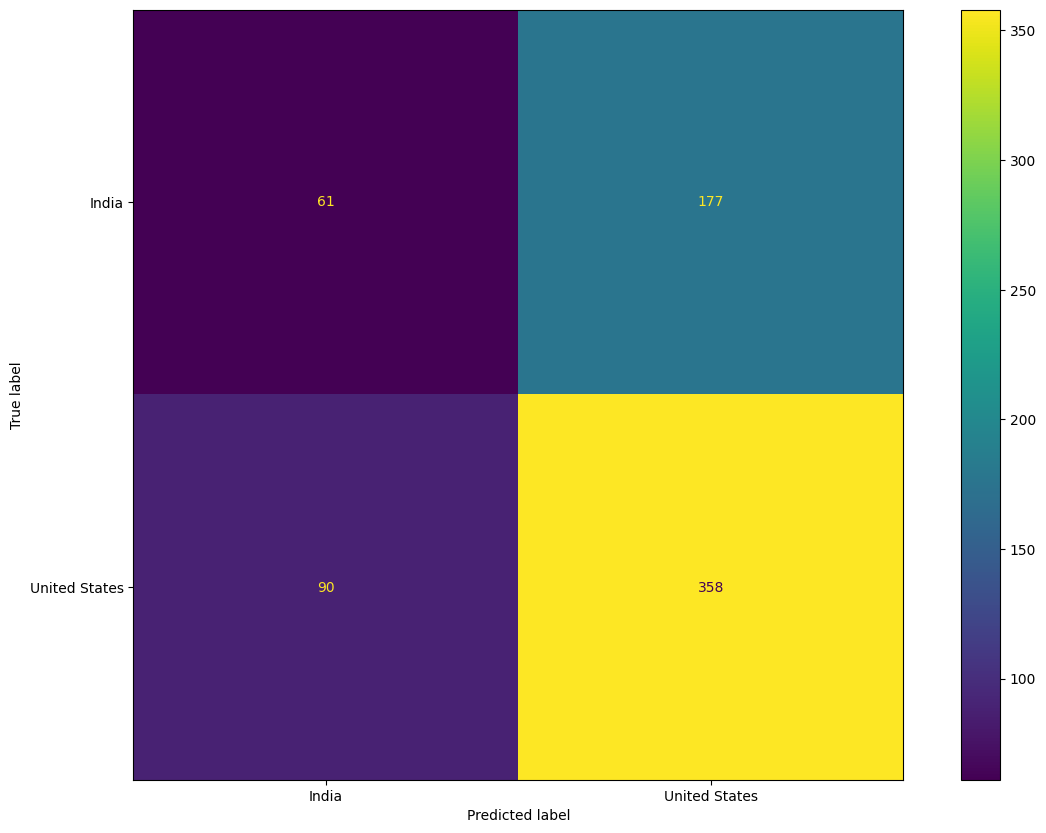

In [ ]:
print(classification_report(y_test, y_test_llm, target_names=enc.classes_))

print("f1_score_macro : ",f1_score(y_test, y_test_llm, average='macro'))
print("f1_score_weighted : ",f1_score(y_test, y_test_llm, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_llm), display_labels=enc.classes_)

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()